# Support Vector Machine

### Import Data & Libraries

In [1]:
import pandas as pd
import numpy as np    
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score  

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# data 
X = abalone.data.features 
y = abalone.data.targets 
  
# metadata 
print(abalone.metadata) 
  
# variable information 
print(abalone.variables) 

{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

In [3]:
y = y.squeeze()

In [4]:
X.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [5]:
X['Sex'] = pd.factorize(X['Sex'])[0]


In [6]:
mask = X["Sex"] != 2
X = X[mask]
y = y[mask]


### Train/Test Split

In [7]:
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                        test_size=test_size,
                                                        random_state=random_state)
    return X_train, X_test, y_train, y_test

In [8]:
X_train, X_test, y_train, y_test = split_data(X, y)


### Hyperparameter Tuning

In [9]:
def tune_svr_model(X_train, y_train):

    # Define the parameter grid
    param_distributions = {
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5, 1.0],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto'],
        'degree': [2, 3, 4]  # only used when kernel='poly'
    }

    # Instantiate the model
    model = SVR()

    random_search = RandomizedSearchCV(estimator=model,
                                    param_distributions=param_distributions,
                                    n_iter=10,
                                    scoring='neg_mean_squared_error',
                                    cv=5,  # Number of cross-validation folds
                                    verbose=2,  # Show process logs
                                    random_state=42,
                                    n_jobs=-1)

    # Fit random search model
    random_search.fit(X_train, y_train)

    # Best model and hyperparameters
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    return best_model, best_params


In [10]:
best_model, best_params = tune_svr_model(X_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [11]:
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.5, 'degree': 2, 'C': 10}


In [12]:
print("Best Model:", best_model)


Best Model: SVR(C=10, degree=2, epsilon=0.5)


### Model

In [ ]:
def SVR_model(X, y, num_replicates=30, test_size=0.2):
    """
    Function to replicate the SVR model,
    perform hyperparameter tuning, and record results.

    Parameters:
    X: Features dataset
    y: Target variable
    num_replicates: Number of replicates to run the experiment
    test_size: Proportion of the dataset to include in the test split

    Returns:
    rmse_list: List of RMSE values from each replicate
    r2_list: List of R² values from each replicate
    best_predictions: Predictions from the best model based on smallest RMSE
    best_model_params: Hyperparameters of the best model based on smallest RMSE
    """
    rmse_list = []
    r2_list = []
    best_rmse = float('inf')
    y_train = None
    best_predictions = None
    best_model_params = None

    for i in range(num_replicates):
        # Train-test split
        X_train, X_test, y_train, y_test = split_data(X, y,
                                                       test_size=test_size,
                                                       random_state=i)

        # Standardize the data 
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Hyperparameter tuning
        best_model, best_params = tune_svr_model(X_train_scaled, y_train)

        # Predict on the test set
        y_pred = best_model.predict(X_test_scaled)

        # Calculate RMSE and R²
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        # Record RMSE and R²
        rmse_list.append(rmse)
        r2_list.append(r2)

        # Update the best model based on the smallest RMSE
        if rmse < best_rmse:
            best_rmse = rmse
            best_predictions = y_pred
            y_test = y_test
            best_model_params = best_params

    return rmse_list, r2_list, best_predictions, y_test, best_model_params

In [14]:
rmse_list, r2_list, best_predictions, y_train, best_model_params = SVR_model(X, y)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each

### Model Evaluation

In [15]:
num_replicates = 30


In [16]:
print(f'RMSE from {num_replicates} replicates {rmse_list}')
print(f'R2 from {num_replicates} replicates {r2_list}')

RMSE from 30 replicates [np.float64(2.4280622454771446), np.float64(2.3051574829715684), np.float64(2.273341761480694), np.float64(2.4686577842894737), np.float64(2.4001005344188386), np.float64(2.0817714325330052), np.float64(2.441805727214189), np.float64(2.4617521259801456), np.float64(2.1731897061878955), np.float64(2.3761339587185635), np.float64(2.335850805729288), np.float64(2.44815915185291), np.float64(2.2566729831041443), np.float64(2.221631121633548), np.float64(2.2375799439956063), np.float64(2.3548232806615603), np.float64(2.216558193347473), np.float64(2.3998920634819885), np.float64(2.352947101068237), np.float64(2.3597104751843108), np.float64(2.5146413076663103), np.float64(2.3015499668487793), np.float64(2.1742959852402914), np.float64(2.2980996408712224), np.float64(2.2346256327158645), np.float64(2.3153520002860306), np.float64(2.2685348660923155), np.float64(2.3495134495327403), np.float64(2.162379869505065), np.float64(2.207236673015722)]
R2 from 30 replicates [0.

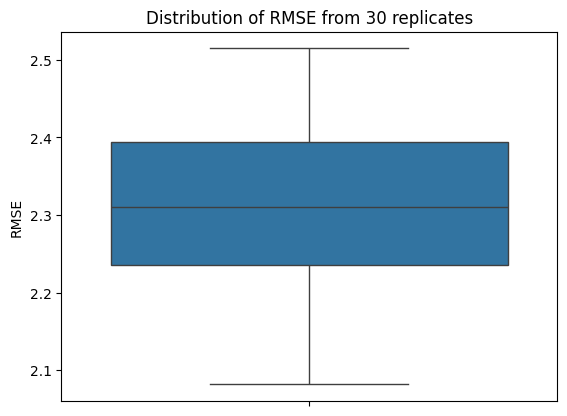

In [17]:
# Create the boxplot
sns.boxplot(data=rmse_list)

# Adding labels and title
plt.title('Distribution of RMSE from 30 replicates')
plt.ylabel('RMSE')

# Show the plot
plt.show()

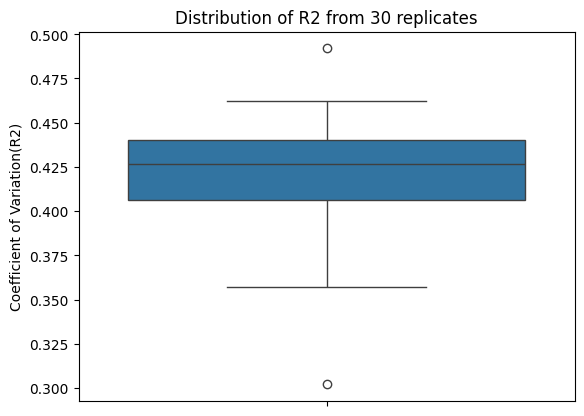

In [18]:
# Create the boxplot
sns.boxplot(data=r2_list)

# Adding labels and title
plt.title('Distribution of R2 from 30 replicates')
plt.ylabel('Coefficient of Variation(R2)')

# Show the plot
plt.show()


In [ ]:
def plot_true_vs_pred(y_true, y_pred):
    # Make both arrays
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()

    # Drop NaN/inf pairs 
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', label='Predicted vs Actual')

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle='--', label='Perfect Prediction')

    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('True vs Predicted Values Scatter Plot')
    plt.legend()
    plt.grid(True)
    plt.show()


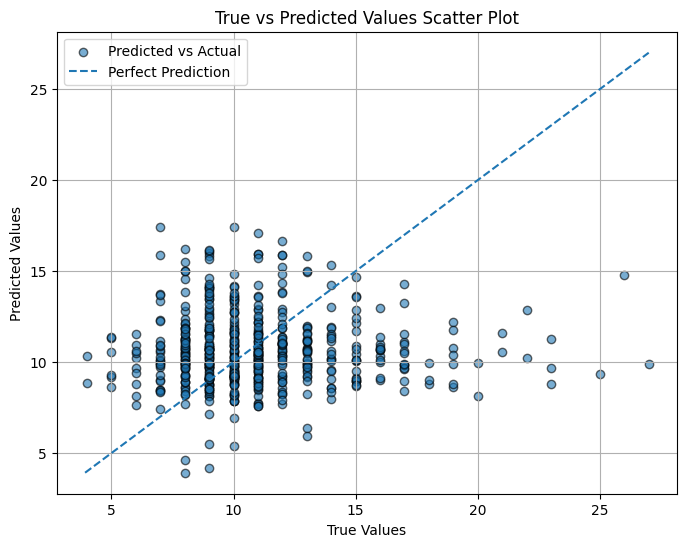

In [20]:
plot_true_vs_pred(y_test, best_predictions)
